# TF-IDF Word Clouds — Manual Implementation

In [59]:
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter, defaultdict
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})

text_df = pd.read_csv("tokenized_wikipage.csv")


## 1 — Parse tokens & build stopwords

In [65]:
def safe_parse(val):
    if not isinstance(val, str): return []
    try:    return ast.literal_eval(val)
    except: return val.split()

text_df["tokens_parsed"] = text_df["tokens_lemmatized"].apply(safe_parse)

# ── Auto-generate name stopwords from the dataset ─────────────────────────────
name_stopwords = set()
for name in text_df["name"].dropna():
    parts = re.sub(r"[^a-zA-Z ]", "", name.lower()).split()
    name_stopwords.update(parts)
print(f"Name-derived stopwords: {len(name_stopwords)}")

# ── Geographic terms that dominate geo-heavy communities ──────────────────────
GEO_STOPWORDS = {
    # California
    "california", "los", "angeles", "san", "francisco", "diego",
    "jose", "sacramento", "fresno", "riverside", "oakland",
    # New York
    "york", "manhattan", "brooklyn", "bronx", "queens", "albany",
    "buffalo", "harlem", "staten", "island",
    # New Jersey
    "jersey", "newark", "camden", "bergen", "essex", "passaic",
    "hunterdon", "rutgers",
    # Alaska / Hawaii
    "alaska", "hawaii", "anchorage", "fairbanks", "honolulu",
    "albuquerque", "pacific", "hawaiian", "alaskan",
    # Generic geographic
    "city", "county", "township", "borough",
    "municipality", "region", "area", "neighborhood",
    "north", "south", "east", "west", "central",
}

# ── Wikipedia boilerplate + generic political terms ───────────────────────────
BOILERPLATE = {
    # Article boilerplate
    "born", "die", "death", "age", "old", "year", "serve", "serving",
    "served", "also", "one", "two", "three", "first", "second", "third",
    "new", "later", "early", "late", "since", "become", "include",
    "many", "well", "make", "take", "give", "come", "go", "know",
    "time", "way", "part", "day", "use", "say", "would", "could",
    "th", "u", "s", "d", "r","man","woman"
    # Generic political terms appearing in every article
    "american", "united", "state", "states", "federal",
    "political", "politician", "politics",
    "member", "congress", "congressional",
    "representative", "senator", "president", "vice",
    "democrat", "republican", "democratic", "party",
    "election", "elect", "elected", "reelect",
    "office", "term", "campaign", "vote", "voting",
    "government", "administration", "official",
    "house", "senate", "committee", "bill", "law",
    "national", "public", "support", "oppose",
    "position", "issue", "school", "university",
    "work", "primary", "general", "local", "special","assemblyman","nominee","nomination",
    "district","mayor","governor","assembly","council","attorney","delegate","secretary","treasurer","commissioner","legislature","legislative","executive","judicial","statehouse","capitol","sub commitee","subcommittee","speaker","chairman","chairwoman","chairperson","leader","leaders","caucus","kansa","lieutenant","court"
    # US state names
    "alabama", "arizona", "arkansas", "colorado", "connecticut","alderman","cuyahoga",
    "delaware", "florida", "georgia", "idaho", "illinois", "indiana",
    "iowa", "kansas", "kentucky", "louisiana", "maine", "maryland",
    "massachusetts", "michigan", "minnesota", "mississippi", "missouri",
    "montana", "nebraska", "nevada", "hampshire", "mexico", "carolina",
    "dakota", "ohio", "oklahoma", "oregon", "pennsylvania", "rhode",
    "tennessee", "texas", "utah", "vermont", "virginia", "washington",
    "wisconsin", "wyoming","chicago","brooklyn","manhattan","cincinnati","columbus","cleveland","detroit","miami","atlanta","boston","memphis","nashville","knoxville","louisville","lexington","richmond","norfolk","virginia beach","portland","salem","eugene","alabama","anchorage","fairbanks","honolulu","albuquerque","pacific","hawaiian","alaskan","houston","dallas","austin","san","antonio","el","paso","san","francisco","san","diego","sacramento","fresno","riverside","oakland"
}

STOPWORDS = name_stopwords | GEO_STOPWORDS | BOILERPLATE

import geonamescache
gc = geonamescache.GeonamesCache()

city_names    = {c["name"].lower() for c in gc.get_cities().values()}
country_names = {c["name"].lower() for c in gc.get_countries().values()}
GEO_AUTO      = city_names | country_names
print(f"Added {len(GEO_AUTO):,} geographic terms from geonamescache")

STOPWORDS = STOPWORDS | GEO_AUTO  




def filter_tokens(token_list):
    return [
        t for t in token_list
        if len(t) >= 3
        and not t.isdigit()
        and not re.match(r'^\d', t)
        and t not in STOPWORDS
        and re.match(r'^[a-z]', t)
    ]

text_df["tokens_filtered"] = text_df["tokens_parsed"].apply(filter_tokens)
text_df["doc_len"]         = text_df["tokens_filtered"].str.len()

df_valid = text_df[text_df["doc_len"] >= 30].copy().reset_index(drop=True)
print(f"Valid documents : {len(df_valid)}")
print(f"Mean doc length : {df_valid['doc_len'].mean():.0f} tokens")
print(f"Median          : {df_valid['doc_len'].median():.0f} tokens")

# Sanity check — sample filtered tokens
sample = df_valid[df_valid["doc_len"] > 100].iloc[0]
print(f"\nSample ({sample['name']}): {sample['tokens_filtered'][:20]}")


Name-derived stopwords: 5314
Added 30,927 geographic terms from geonamescache
Valid documents : 5712
Mean doc length : 516 tokens
Median          : 262 tokens

Sample (Stephen Miller): ['american', 'advisor', 'deputy', 'chief', 'staff', 'policy', 'homeland', 'security', 'advisor', 'previously', 'senior', 'advisor', 'director', 'speechwriting', 'consider', 'influential', 'figure', 'trumpism', 'movement', 'described']


## 2 — Manual TF-IDF

**TF** is computed per individual document:
$$TF(t, d) = \log\left(1 + \frac{\text{count}(t, d)}{|d|}\right)$$

**IDF** is computed across all individual articles (not communities):
$$IDF(t) = \log\left(\frac{N}{df(t)}\right)$$

This ensures names like "Obama" that appear in thousands of articles get near-zero IDF,
while distinctive policy terms that appear in only a subset get high IDF.


In [66]:

def compute_tf(token_list):
    n      = len(token_list)
    counts = Counter(token_list)
    return {term: np.log(1 + count / n) for term, count in counts.items()}

print("Computing TF for all documents...")
tf_per_doc = [compute_tf(tokens) for tokens in df_valid["tokens_filtered"]]
print(f"  Done — {len(tf_per_doc)} documents")

# ── Step 2: Document frequency across all articles ────────────────────────────
print("Computing document frequencies...")
N        = len(df_valid)
doc_freq = defaultdict(int)

for token_list in df_valid["tokens_filtered"]:
    for term in set(token_list):    # set() — count each term once per doc
        doc_freq[term] += 1

# Apply min/max DF filter to remove very rare and very common terms
MIN_DF = 10            # must appear in at least 10 articles
MAX_DF = int(0.45 * N) # must appear in at most 45% of articles

print(f"  Total unique terms before filter : {len(doc_freq):,}")
doc_freq_filtered = {
    term: count for term, count in doc_freq.items()
    if MIN_DF <= count <= MAX_DF
}
print(f"  Vocabulary after DF filter       : {len(doc_freq_filtered):,}")

# ── Step 3: IDF ───────────────────────────────────────────────────────────────
idf_dict = {
    term: np.log(N / count)
    for term, count in doc_freq_filtered.items()
}

# ── Step 4: TF-IDF per document ───────────────────────────────────────────────
print("Computing TF-IDF per document...")
tfidf_per_doc = [
    {term: tf * idf_dict[term]
     for term, tf in doc_tf.items()
     if term in idf_dict}
    for doc_tf in tf_per_doc
]
print("  Done")


Computing TF for all documents...
  Done — 5712 documents
Computing document frequencies...
  Total unique terms before filter : 78,342
  Vocabulary after DF filter       : 11,257
Computing TF-IDF per document...
  Done


## 3 — Group aggregation

In [67]:
def group_tfidf(df_subset, top_n=80):
    """
    Average TF-IDF across all documents in df_subset.
    Returns top_n {term: avg_score} dict.
    """
    indices = df_valid.index.get_indexer(df_subset.index)
    indices = indices[indices >= 0]
    if len(indices) == 0:
        return {}

    agg = defaultdict(float)
    for i in indices:
        for term, score in tfidf_per_doc[i].items():
            agg[term] += score

    n   = len(indices)
    avg = {term: total / n for term, total in agg.items()}
    return dict(sorted(avg.items(), key=lambda x: x[1], reverse=True)[:top_n])


## 4 — Party word clouds


Democrat top 10 terms:
  health                          0.00265
  court                           0.00263
  chair                           0.00258
  woman                           0.00253
  award                           0.00248
  director                        0.00239
  community                       0.00232
  war                             0.00230
  appoint                         0.00230
  practice                        0.00229

Republican top 10 terms:
  percent                         0.00297
  tax                             0.00291
  court                           0.00283
  conservative                    0.00260
  unopposed                       0.00248
  army                            0.00239
  appoint                         0.00236
  company                         0.00231
  succeed                         0.00229
  race                            0.00226


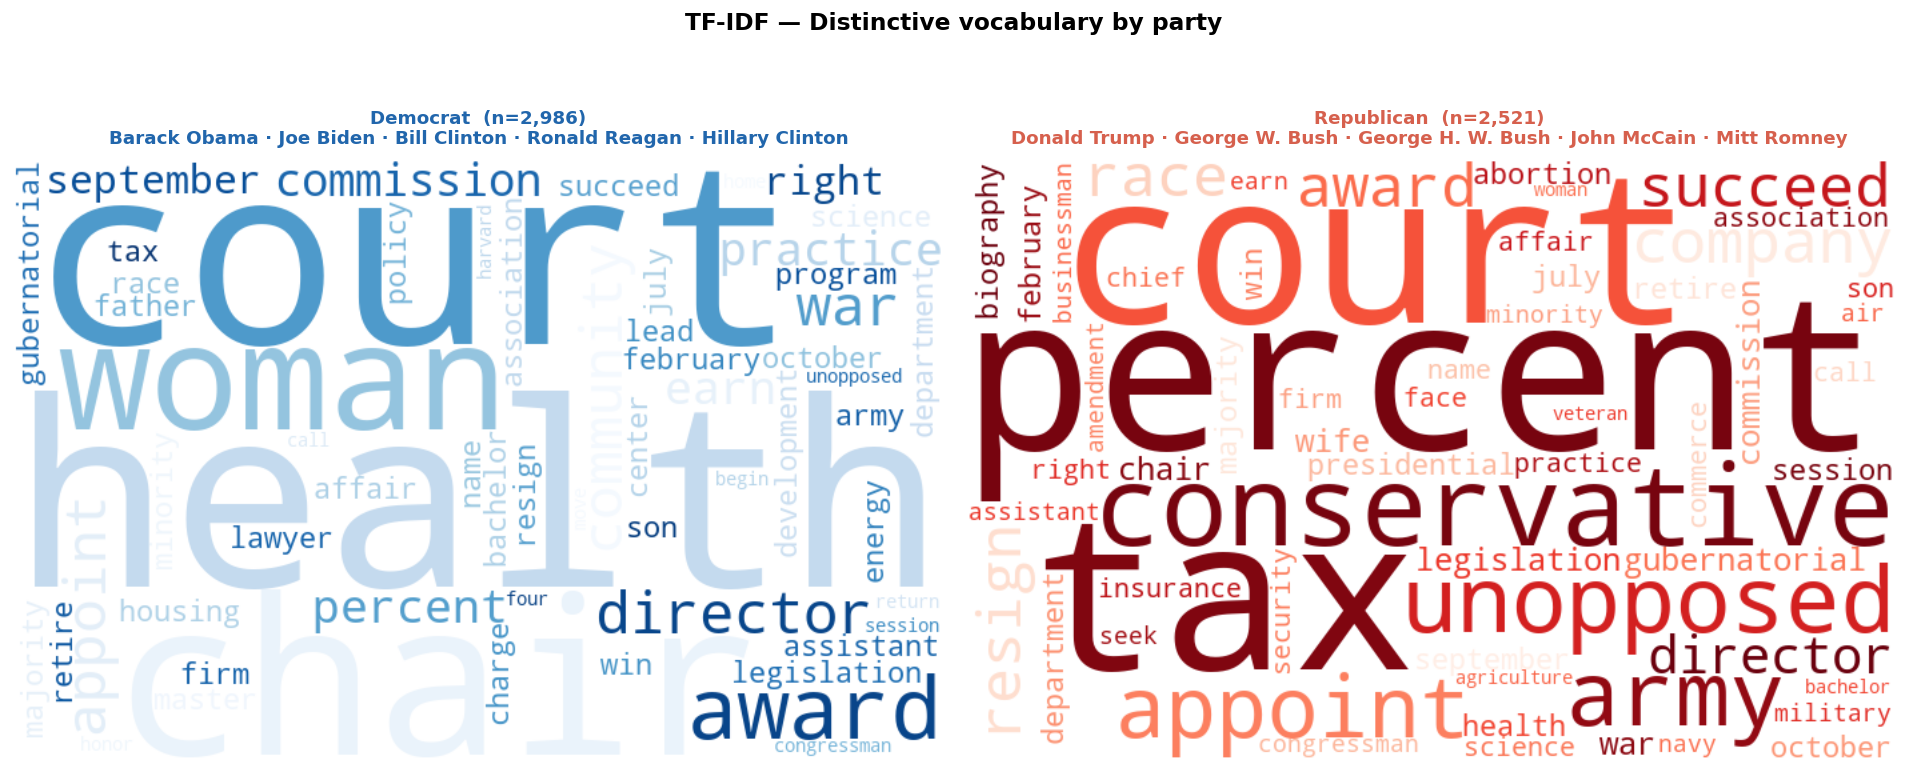

Saved → tfidf_party.png


In [68]:
PARTY_COLORS = {"Democrat": "#2166ac", "Republican": "#d6604d"}

party_terms = {}
for party in ["Democrat", "Republican"]:
    subset              = df_valid[df_valid["party"] == party]
    party_terms[party]  = group_tfidf(subset)

    print(f"\n{party} top 10 terms:")
    for term, score in list(party_terms[party].items())[:10]:
        print(f"  {term:30s}  {score:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (party, terms) in zip(axes, party_terms.items()):
    cmap = "Blues" if party == "Democrat" else "Reds"
    n    = len(df_valid[df_valid["party"] == party])

    top5 = (df_valid[df_valid["party"] == party]
            .dropna(subset=["degree"])
            .nlargest(5, "degree")["name"].tolist())

    wc = WordCloud(
        width=700, height=450, background_color="white",
        colormap=cmap, max_words=60,
        prefer_horizontal=0.85, min_font_size=9, collocations=False,
    ).generate_from_frequencies(terms)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(
        f"{party}  (n={n:,})\n" + " · ".join(top5),
        fontsize=11, fontweight="bold", pad=10,
        color=PARTY_COLORS[party]
    )
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary by party",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_party.png")


## 5 — Community word clouds

Computing community TF-IDF...
  Community  15 (n= 775): ['war', 'army', 'percent', 'presidential', 'award']
  Community   2 (n= 645): ['court', 'unopposed', 'director', 'health', 'september']
  Community   5 (n= 614): ['unopposed', 'runoff', 'percent', 'chair', 'session']
  Community  30 (n= 354): ['supervisor', 'valley', 'santa', 'latino', 'chula']
  Community   6 (n= 254): ['queen', 'comptroller', 'sit', 'town', 'community']
  Community   7 (n= 241): ['freeholder', 'seton', 'chosen', 'resident', 'amboy']
  Community  22 (n= 237): ['committeeman', 'comptroller', 'tax', 'appoint', 'commerce']
  Community  19 (n= 174): ['maui', 'gubernatorial', 'oil', 'valdez', 'native']
  Community  16 (n= 172): ['minority', 'resign', 'replace', 'limit', 'court']


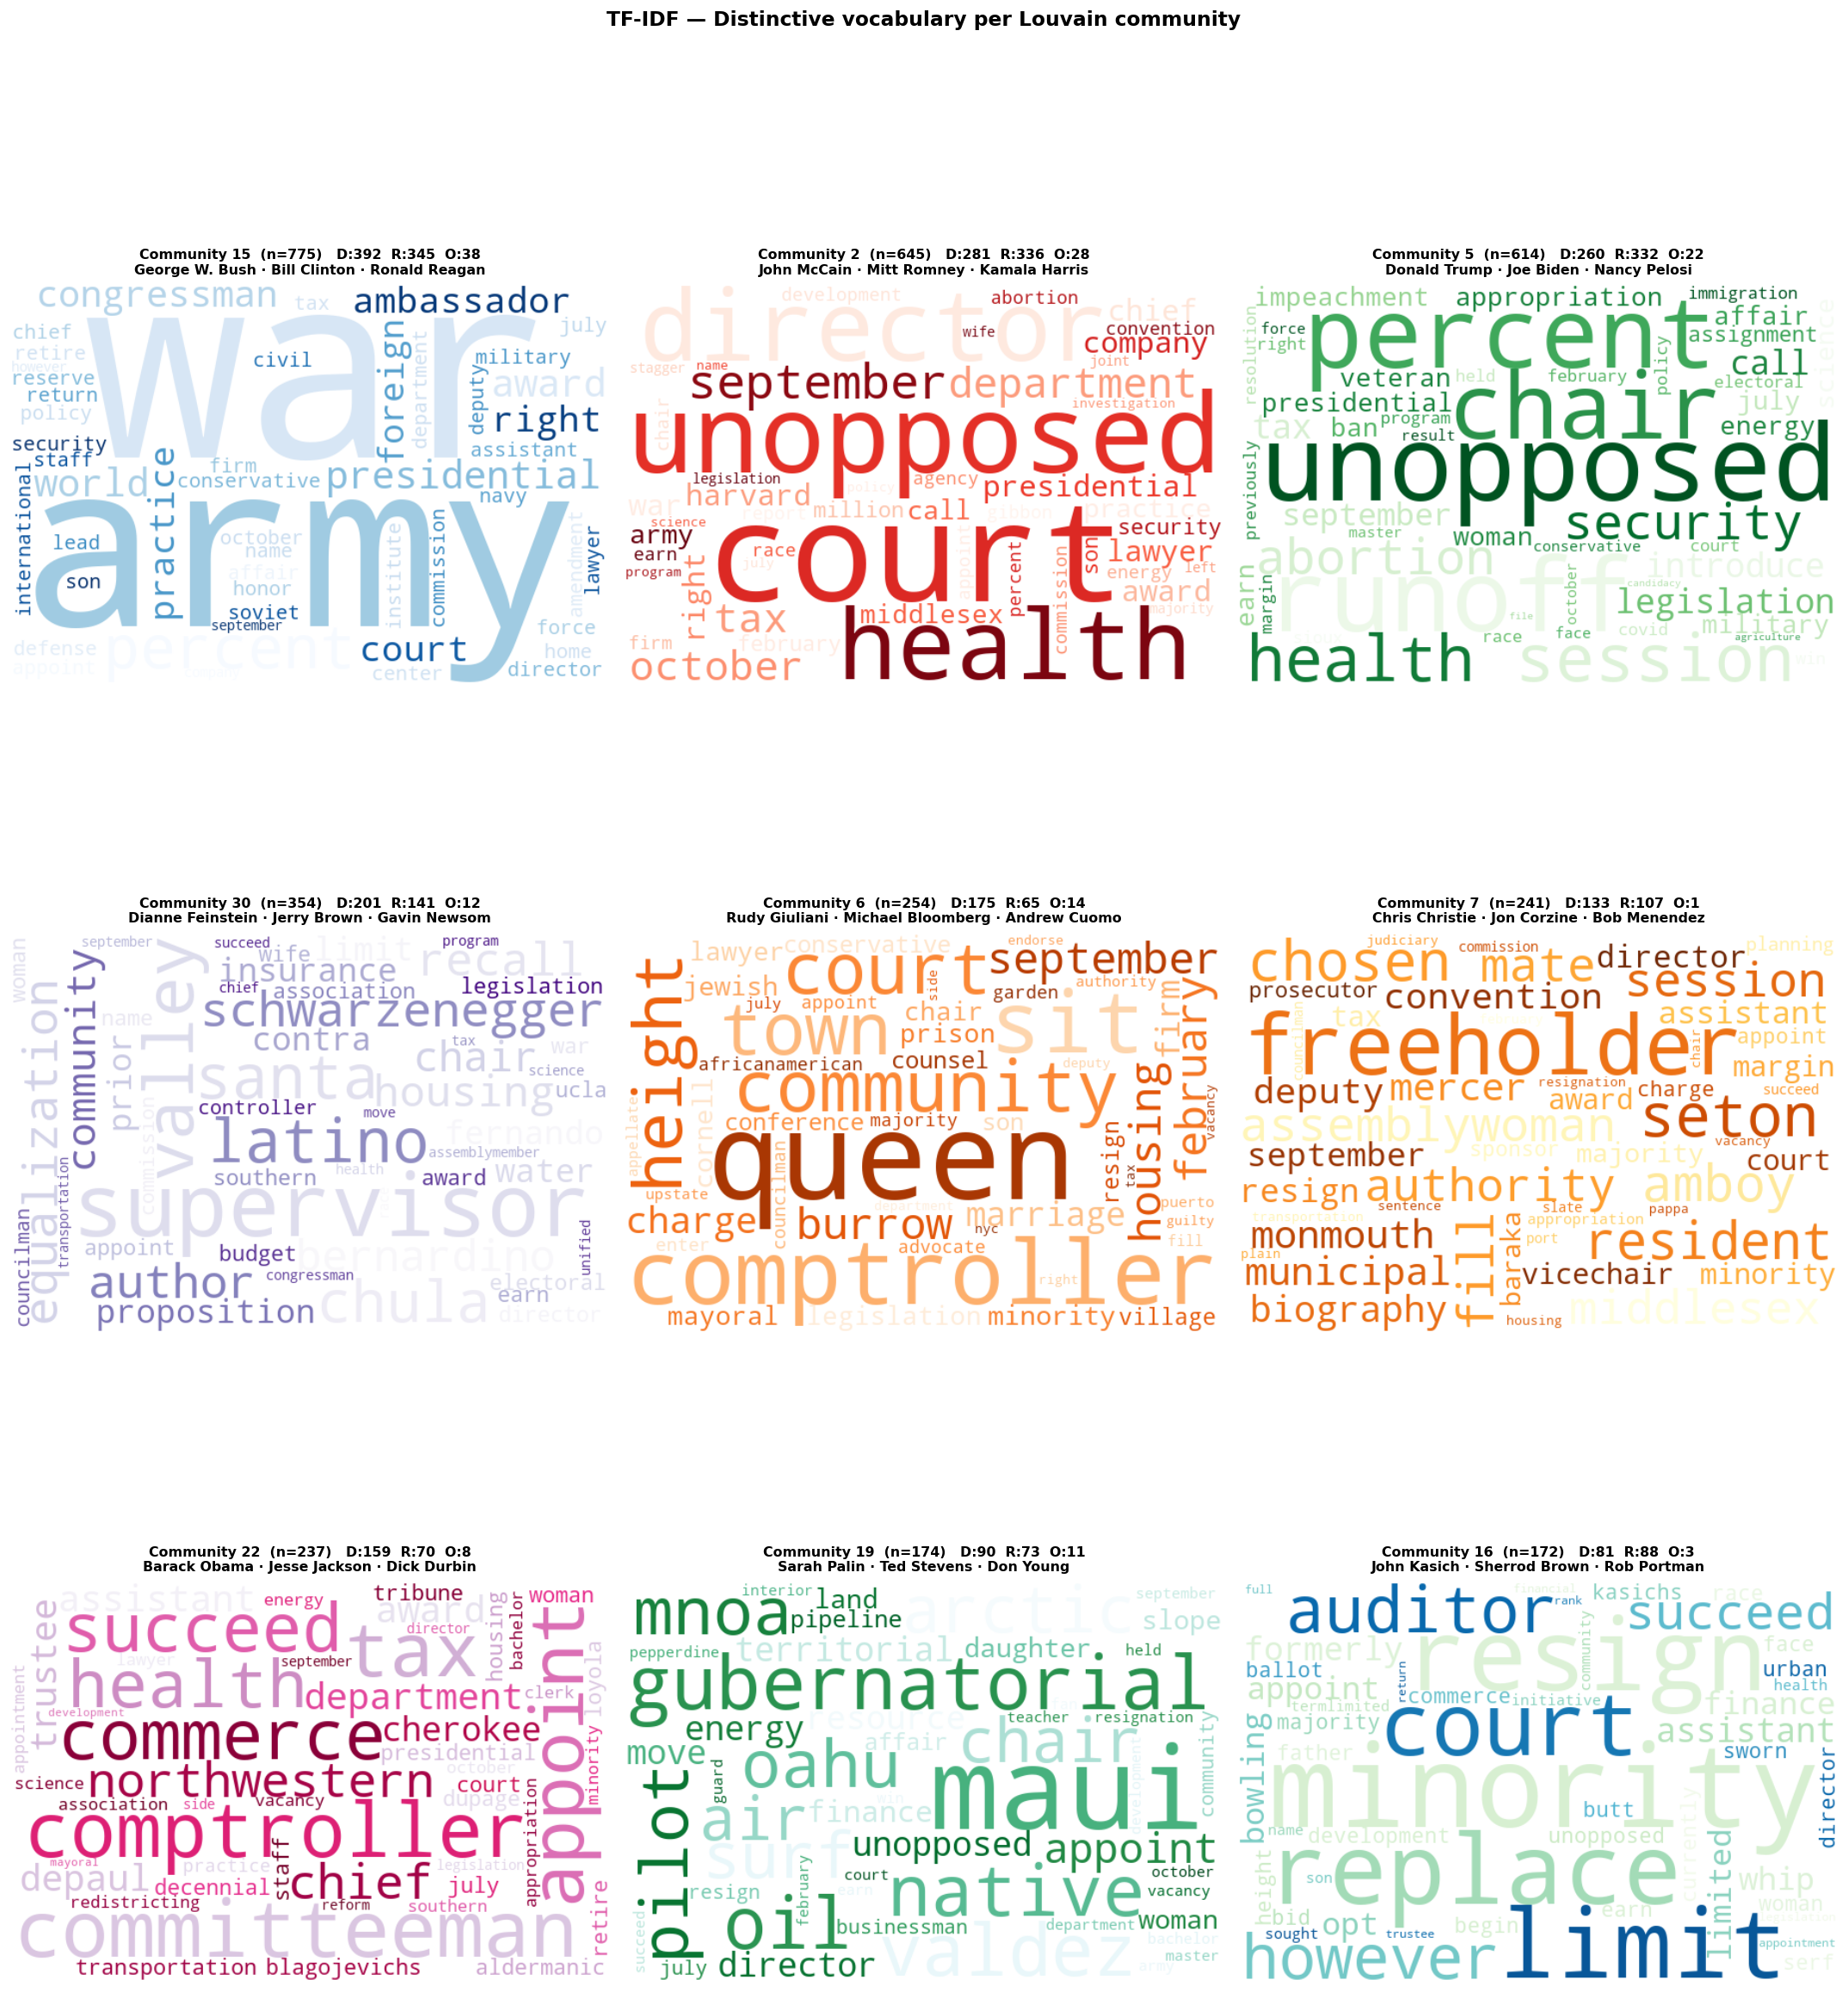

Saved → tfidf_communities.png


In [69]:
community_sizes = df_valid["community"].value_counts()
top_communities = community_sizes[community_sizes >= 50].head(9).index.tolist()

print("Computing community TF-IDF...")
comm_terms = {}
for cid in top_communities:
    subset        = df_valid[df_valid["community"] == cid]
    comm_terms[cid] = group_tfidf(subset)
    top5          = list(comm_terms[cid].keys())[:5]
    print(f"  Community {int(cid):3d} (n={int(community_sizes[cid]):4d}): {top5}")

CMAPS = ["Blues","Reds","Greens","Purples","Oranges",
         "YlOrBr","PuRd","BuGn","GnBu"]

n_cols = 3
n_rows = (len(top_communities) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, 7 * n_rows), facecolor="white")
axes_flat = list(axes.flat)

for ax, cid, cmap in zip(axes_flat, top_communities, CMAPS):
    terms = comm_terms[cid]
    if not terms:
        ax.axis("off")
        continue

    wc = WordCloud(
        width=600, height=400, background_color="white",
        colormap=cmap, max_words=50,
        prefer_horizontal=0.85, min_font_size=9, collocations=False,
    ).generate_from_frequencies(terms)
    ax.imshow(wc, interpolation="bilinear")

    n          = int(community_sizes[cid])
    party_comp = df_valid[df_valid["community"] == cid]["party"].value_counts()
    d = party_comp.get("Democrat",   0)
    r = party_comp.get("Republican", 0)
    o = party_comp.get("Other",      0)

    top3_names = (df_valid[df_valid["community"] == cid]
                  .dropna(subset=["degree"])
                  .nlargest(3, "degree")["name"].tolist())

    ax.set_title(
        f"Community {int(cid)}  (n={n})   D:{d}  R:{r}  O:{o}\n"
        + " · ".join(top3_names),
        fontsize=9.5, fontweight="bold", pad=8,
    )
    ax.axis("off")

for ax in axes_flat[len(top_communities):]:
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary per Louvain community",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_communities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_communities.png")
